# Part 1: Graphical Analysis

### 1. Scatter Diagram (10 points)
- Choose a dataset (from UCI Machine Learning Repository).
- Create a scatter diagram to visualize the relationship between two numerical variables.
- Describe the relationship you observe. Is it linear, non-linear, or no correlation? Provide a brief interpretation of your findings.

#### Dataset Introduction
**Wine Quality** 

Link to the dataset: [link](https://archive.ics.uci.edu/dataset/186/wine+quality) \
The Wine quality dataset containes physicochemical properties of Portuguese Vinho Verde along with labled qualities ranging from 0 (very poor) to 10 (excellent). There are two datasets created, one for red wine and one for red wines. For this assignment purpose, only white wine dataset is being used which has 4898 instances, 11 features and a target attribute. 

In [16]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [17]:
df = pd.read_csv('data/winequality-red.csv', delimiter=';')
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')
print(df.shape)
df.head(5)

(1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


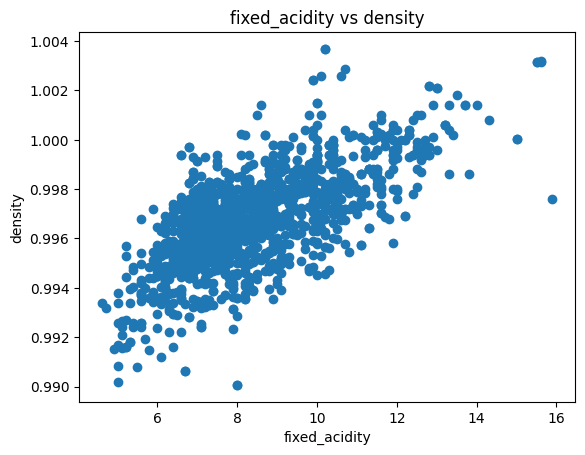

In [18]:
attribute1='fixed_acidity'
attribute2='density'
x = df[attribute1]
y = df[attribute2]
plt.scatter(x, y)
plt.xlabel(attribute1)
plt.ylabel(attribute2)
plt.title(attribute1 + ' vs ' + attribute2)
plt.show()

*Relationship between fixed acidity and density*

The above scatter diagram shows the general trend of increasing density with increase in fixed acidity. This shows that there is strong linear positive correlation between fixed acidity and density.

----

### 2. Q-Q Plot (10 points)
- Using the same dataset, create a Q-Q plot to assess the normality of one of the numerical variables.
- Explain what a Q-Q plot is and how to interpret it. Does the data appear to follow a normal distribution? Justify your answer.

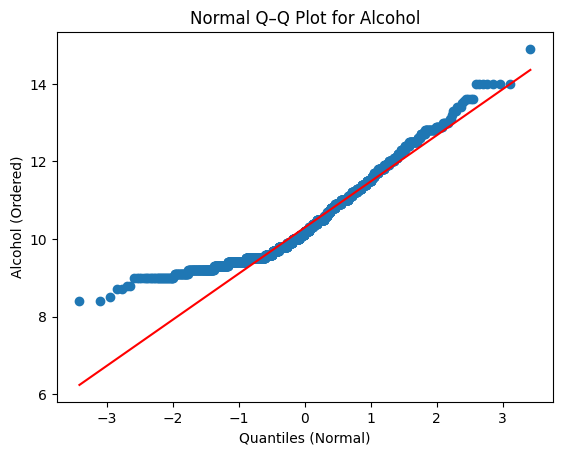

In [19]:
from scipy.stats import norm


plotdata = (
    df['alcohol']
    .sort_values()
    .reset_index(drop=True)
    .to_frame(name='alcohol')
)

# calculate the probabilies representing rank in the data
n = len(plotdata['alcohol'])
plotdata['p'] = (np.arange(1,n+1) - 0.5) / n

# calculate the quanties 
plotdata['q'] = norm.ppf(plotdata['p'])

# find the reference line
Q1_sample, Q3_sample = np.percentile(plotdata['alcohol'], [25, 75])
Q1_theor, Q3_theor = np.percentile(plotdata['q'], [25, 75])

slope = (Q3_sample - Q1_sample) / (Q3_theor - Q1_theor)
intercept = Q1_sample - slope * Q1_theor
 

plt.scatter(plotdata['q'], plotdata['alcohol'])
plt.plot(plotdata['q'], intercept + slope*plotdata['q'], color='red', label='Reference line')
plt.xlabel("Quantiles (Normal)")
plt.ylabel("Alcohol (Ordered)")
plt.title("Normal Q–Q Plot for Alcohol")
plt.show()



Q-Q plot is graphical view to check whether the data comes from some theoritical distribution such as normal distribution by comparing the quantiles of the observerd data to the quantile of the assumed distribution. Here, we are trying to access normality of the variable alcohol.  

This generated plot shows that the alcohol data are approximately normal but not perfectly distributed. 
There is some deviations around the tails. Lowest alcohol values are higher than expected under normality. Also there is some extreme values in higer alcohol values. 

---

### 3. Box Plots (10 points)
- Generate box plots for the numerical variable across different categories of a categorical variable in your dataset.
- Analyze the box plots and discuss any outliers, the spread of the data.


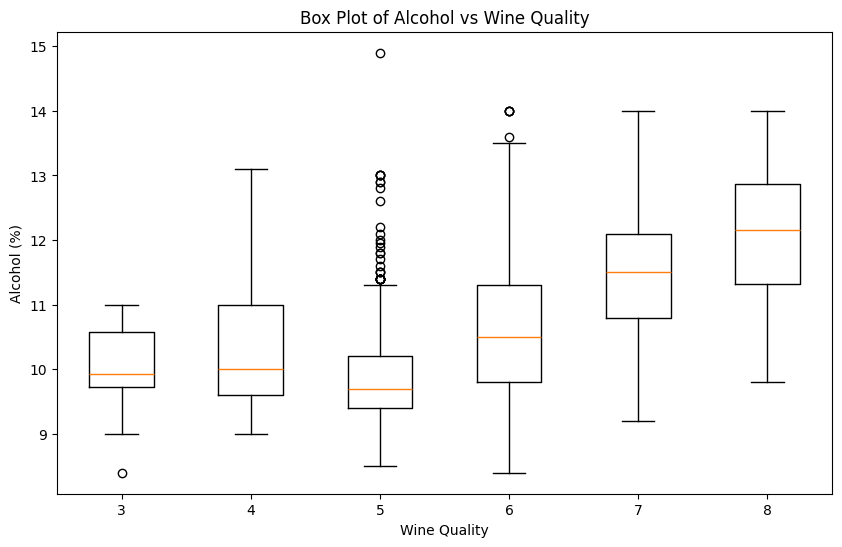

In [20]:
qualities = sorted(df['quality'].unique())
alcohol_by_quality = [df[df['quality'] == q]['alcohol'] for q in qualities]

plt.figure(figsize=(10,6))
plt.boxplot(alcohol_by_quality, tick_labels=qualities)
plt.title('Box Plot of Alcohol vs Wine Quality')
plt.xlabel('Wine Quality')
plt.ylabel('Alcohol (%)')
plt.show()

- The median line increases from quality 3 gto 8. This shows that the better wine tends to have higher alcohol content.
- The higher quality wine generally tends to have greater variability on alcohol content given by longer box (ie, IQR range).
- There is presence of outliers in wines with quality score of 5 and 6. In both cases there are wines with unusually high alcohol content compared to wines in same quality category.

___
---

# Part 2: Statistical Analysis

### 4. Normality Test (10 points)
   - Perform a normality test (e.g., Shapiro-Wilk test) on the numerical variable you analyzed.
   - Report the test statistic and p-value. Based on these results, do you reject or fail to reject the null hypothesis of normality? Explain your reasoning.

Null Hypothesis (H<sub>0</sub>): The alcohol data are normally distributed. \
Alternate Hypthesis (H<sub>1</sub>): The alcohol data not normally distributed. \
Significance level(&alpha;) = 0.05

In [23]:
from scipy.stats import shapiro
W, p_value = shapiro(df["alcohol"])
W, p_value

(np.float64(0.9288390813054377), np.float64(6.644056905730039e-27))

Here, the test produced Shapiro-Wilk statistic of W=0.92 with corresponding p value = 6.64e-27. Using significance level of &alpha; = 0.05, p-value is less than 0.05. Therefore we reject null hypthesis. This indicates alcohol variable does not follow a normal distribution.

---

### 5. Correlation and Covariance (10 points)
   - Calculate the correlation coefficient and covariance between the two numerical variables you used in the scatter diagram.
   - Interpret the results. What do they tell you about the relationship between these variables?

In [38]:
import math


data_df = pd.DataFrame({
    'X' : df['fixed_acidity'].values,
    'Y' : df['density'].values 
}) 
n = len(data_df['X'])
mean_X = sum(data_df['X']) / n
mean_Y = sum(data_df['Y']) / n

data_df['X_distance_from_mean'] = data_df['X'] - mean_X
data_df['Y_distance_from_mean'] = data_df['Y'] - mean_Y
data_df['product_X_Y_distance_from_mean'] = data_df['X_distance_from_mean']  * data_df['Y_distance_from_mean'] 
data_df['X_distance_from_mean_squared'] = data_df['X_distance_from_mean']**2
data_df['Y_distance_from_mean_squared'] = data_df['Y_distance_from_mean']**2

cov_X_Y = sum(data_df['product_X_Y_distance_from_mean']) / n
var_X = sum(data_df['X_distance_from_mean_squared']) / n
var_Y = sum(data_df['Y_distance_from_mean_squared']) / n

corr_coef = cov_X_Y / ( math.sqrt(var_X) * math.sqrt(var_Y) )

print(f"Covariance = {cov_X_Y:.4f}")
print(f"Correlation Coefficient = {corr_coef:.4f}")

Covariance = 0.0022
Correlation Coefficient = 0.6680


- The covariance of 0.002 suggests positive relationship between the tow variables. 
- The correlation coefficient of 0.66 suggests moderate positive relationship between fixed acidity and density of wine. 
- This means as acidity of wine increases density also increases. 